In [ ]:
# FAZA 8 — Objašnjivo mašinsko učenje (XAI): SHAP analiza najboljeg modela
#
# Prethodne faze su odgovarale na pitanje koliko dobro model radi. Ova faza
# odgovara na pitanje zašto model donosi odluke koje donosi i da li se ta
# objašnjenja poklapaju sa teorijom o lateralnom kretanju iz uvodnog dela rada.
#
# Analizira se Random Forest iz Faze 4 (celokupni pobednik projekta). Za
# modele bazirane na stablu postoji TreeExplainer, koji računa tačne SHAP vrednosti,
# bez aproksimacije koju bi zahtevale neuronske mreže.
#
# Radi se na validacionom skupu, a ne na test skupu. SHAP je alat za razumevanje
# modela, ne za merenje performansi, pa nema razloga da se test ponovo dira
# posle finalne evaluacije u Fazi 7. Validacija ima i više pozitivnih primera
# pa je pogodnija za analizu.

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap

PROC = Path(__file__).resolve().parent.parent / "data" / "processed"
RESULTS = Path(__file__).resolve().parent.parent / "results"
MODELS = Path(__file__).resolve().parent.parent / "models"

SEED = 7
np.random.seed(SEED)

In [ ]:
# --- 1. Učitavanje podataka i modela iz Faze 4 ---
vremenski_prozori = pd.read_parquet(PROC / "features.parquet")

with open(PROC / "imputation_values.json", encoding="utf-8") as f:
    imputation_values = json.load(f)
with open(MODELS / "faza4_konfiguracija.json", encoding="utf-8") as f:
    konfig_4 = json.load(f)

vremenski_prozori["has_history"] = (vremenski_prozori["window_seq_num"] >= 1).astype(
    int
)
for kolona, vrednost in imputation_values.items():
    if kolona in vremenski_prozori.columns:
        vremenski_prozori[kolona] = vremenski_prozori[kolona].fillna(vrednost)

val = vremenski_prozori[vremenski_prozori["split"] == "valid"].reset_index(drop=True)
y_val = val["is_attack"]

model = joblib.load(MODELS / "faza4_najbolji_model.pkl")
kolone = konfig_4["kolone"]
X_val = val[kolone]

print(f"Model: {konfig_4['model']} ({konfig_4['skup_atributa']})")
print(f"Validacija: {len(val)} redova, {int(y_val.sum())} pozitivnih")
print(f"Atributa u modelu: {len(kolone)}")

Model: RandomForest (Filter (40))
Validacija: 17630 redova, 115 pozitivnih
Atributa u modelu: 40


In [ ]:
# --- 2. Računanje SHAP vrednosti ---
# TreeExplainer prolazi kroz strukturu stabala i za svaki red računa koliko je
# svaki atribut doprineo pomeranju predikcije od osnovne vrednosti (prosečna
# predikcija modela) ka konačnoj predikciji za taj red. Pozitivna SHAP vrednost
# gura predikciju ka klasi napada, negativna ka normalnom prozoru.
explainer = shap.TreeExplainer(model)
shap_vrednosti = explainer.shap_values(X_val)

# Za binarnu klasifikaciju sklearn vraća listu od dva niza (klasa 0 i klasa 1)
# ili trodimenzionalni niz. Uzima se doprinos klasi 1 (napad).
if isinstance(shap_vrednosti, list):
    shap_napad = shap_vrednosti[1]
elif shap_vrednosti.ndim == 3:
    shap_napad = shap_vrednosti[:, :, 1]
else:
    shap_napad = shap_vrednosti

print("Oblik SHAP matrice:", shap_napad.shape)
print("(jedan red po prozoru, jedna kolona po atributu)")

Oblik SHAP matrice: (17630, 40)
(jedan red po prozoru, jedna kolona po atributu)


In [ ]:
# --- 3. Rangiranje atributa po prosečnom apsolutnom SHAP doprinosu ---
# Apsolutna vrednost se koristi jer nas ovde zanima jačina uticaja, bez obzira
# da li atribut gura ka napadu ili od njega.
prosecan_shap = np.abs(shap_napad).mean(axis=0)
rangiranje = pd.DataFrame(
    {"Atribut": kolone, "Prosečan |SHAP|": prosecan_shap}
).sort_values("Prosečan |SHAP|", ascending=False)

print("Rangiranje atributa po uticaju na predikciju:")
print(rangiranje.to_string(index=False))

rangiranje.to_csv(RESULTS / "faza8_shap_rangiranje.csv", index=False)
print("\nSačuvano: results/faza8_shap_rangiranje.csv")

# Uočava se da su najuticajniji atributi deo NTLM porodice atributa (4 od 5 najuticajnijih).

Rangiranje atributa po uticaju na predikciju:
            Atribut  Prosečan |SHAP|
         ntlm_ratio         0.001774
       n_ntlm_delta         0.001187
             n_ntlm         0.001132
     window_seq_num         0.001034
           n_ntlm_z         0.001018
  n_dst_seen_before         0.000716
        n_ntlm_ma24         0.000652
          n_new_dst         0.000643
      new_dst_ratio         0.000619
     events_per_dst         0.000609
        day_of_week         0.000542
        hour_of_day         0.000530
         n_src_comp         0.000428
    n_src_comp_sd24         0.000424
           n_events         0.000340
       n_src_comp_z         0.000276
    n_src_comp_lag1         0.000266
       n_auth_types         0.000220
         n_kerberos         0.000214
      n_events_ma24         0.000196
         n_events_z         0.000162
     kerberos_ratio         0.000136
    n_dst_comp_ma24         0.000129
      n_events_lag1         0.000115
 auth_unknown_ratio         0

<ipython-input-5-19ad3d37edfa>:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_napad, X_val, plot_type="bar", show=False)


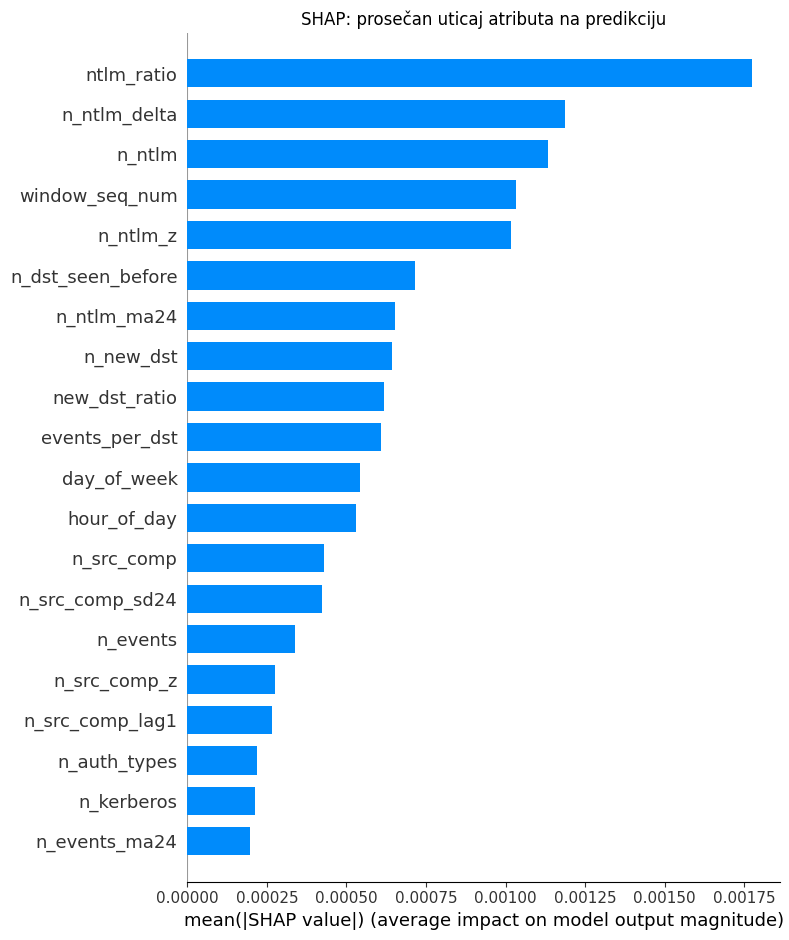

Grafik sačuvan: results/faza8_shap_bar.png


In [ ]:
# --- 4. Bar plot: ukupan značaj atributa ---
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_napad, X_val, plot_type="bar", show=False)
plt.title("SHAP: prosečan uticaj atributa na predikciju")
plt.tight_layout()
plt.savefig(RESULTS / "faza8_shap_bar.png", dpi=120)
plt.show()
print("Grafik sačuvan: results/faza8_shap_bar.png")

<ipython-input-6-9dba1b4b9abf>:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_napad, X_val, show=False)


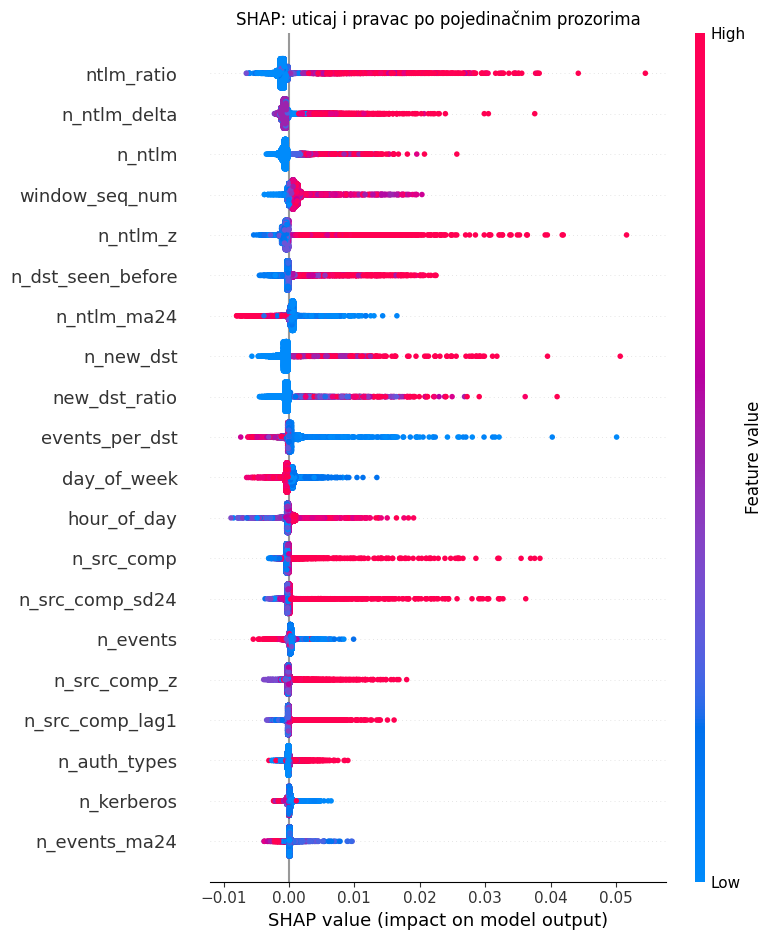

Grafik sačuvan: results/faza8_shap_summary.png


In [ ]:
# --- 5. Summary plot: uticaj i pravac po svakom prozoru ---
# Svaka tačka je jedan prozor. Položaj levo ili desno pokazuje da li je taj
# atribut u tom prozoru gurnuo predikciju ka normalnom ili ka napadu, a boja
# pokazuje da li je vrednost samog atributa bila niska ili visoka. Ovaj grafik
# otkriva ne samo koji atributi utiču, nego i kako.
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_napad, X_val, show=False)
plt.title("SHAP: uticaj i pravac po pojedinačnim prozorima")
plt.tight_layout()
plt.savefig(RESULTS / "faza8_shap_summary.png", dpi=120)
plt.show()
print("Grafik sačuvan: results/faza8_shap_summary.png")

# NTLM porodica (ntlm_ratio, n_ntlm_delta, n_ntlm, n_ntlm_z) pored toga što je uticajna, ima i dosledan smer. Visoke vrednosti (crveno) guraju
# predikciju ka napadu, u skladu sa NTLM-om kao poznatim vektorom lateralnog
# kretanja (Pass-the-hash). Isti obrazac imaju n_new_dst i new_dst_ratio:
# više novih odredišnih računara gura ka napadu, što se poklapa sa definicijom
# lateralnog kretanja.
# events_per_dst ide u suprotnom smeru:
# niska vrednost (razuđena aktivnost na više mašina umesto grupisana na
# jednoj) gura ka napadu.

In [ ]:
# --- 6. Objašnjenje pojedinačnih napada ---
# Do sada je analiza bila globalna, na nivou celog modela. Ovde se gleda zašto
# je model označio konkretan prozor kao napad. Biraju se tri stvarna napada
# kojima je model dao najvišu verovatnoću, jer su to slučajevi u kojima je
# model bio najsigurniji i gde je objašnjenje najčitljivije.
p_val = model.predict_proba(X_val)[:, 1]
indeksi_napada = np.where(y_val == 1)[0]
najsigurniji = indeksi_napada[np.argsort(p_val[indeksi_napada])[-3:][::-1]]

for redni_broj, idx in enumerate(najsigurniji, start=1):
    print(
        f"\nNapad {redni_broj}: red {idx}, entitet {val.loc[idx, 'entity']}, "
        f"dan {val.loc[idx, 'day']}, verovatnoća {p_val[idx]:.4f}"
    )

    doprinosi = pd.DataFrame(
        {"Atribut": kolone, "SHAP": shap_napad[idx], "Vrednost": X_val.iloc[idx].values}
    )
    doprinosi["|SHAP|"] = doprinosi["SHAP"].abs()
    doprinosi = doprinosi.sort_values("|SHAP|", ascending=False).head(6)
    print(doprinosi[["Atribut", "Vrednost", "SHAP"]].to_string(index=False))

# Ni najsigurniji napadi koji je model prepoznao ne prelazi verovatnoću 0.5
# (0.4334, 0.2863, 0.2212). Predstavljaju posledicu ekstremnog disbalansa iz trening skupa.
# Ovo potvrđuje zašto je u Fazi 4 izabran prag 0.0915 umesto standardnog 0.5. Na pragu 0.5
# model ne bi uhvatio čak ni ova tri najočiglednija slučaja.


Napad 1: red 6024, entitet U3005, dan 13, verovatnoća 0.4334
       Atribut  Vrednost     SHAP
    ntlm_ratio  0.333333 0.054499
      n_ntlm_z  7.399461 0.051627
     n_new_dst  8.000000 0.050657
events_per_dst  2.250000 0.050104
 new_dst_ratio  0.500000 0.041006
  n_ntlm_delta  6.000000 0.037586

Napad 2: red 7553, entitet U3635, dan 14, verovatnoća 0.2863
      Atribut  Vrednost     SHAP
    n_new_dst 47.000000 0.039539
     n_ntlm_z 28.262291 0.036354
new_dst_ratio  0.691176 0.029091
   ntlm_ratio  0.044944 0.026915
   n_src_comp 60.000000 0.025779
 n_ntlm_delta 23.000000 0.023916

Napad 3: red 711, entitet U1145, dan 13, verovatnoća 0.2212
          Atribut  Vrednost     SHAP
         n_ntlm_z 21.359289 0.032650
       n_src_comp 24.000000 0.032130
       ntlm_ratio  0.122449 0.030106
        n_new_dst  5.000000 0.029662
     n_ntlm_delta 17.000000 0.021304
n_dst_seen_before 64.000000 0.017990


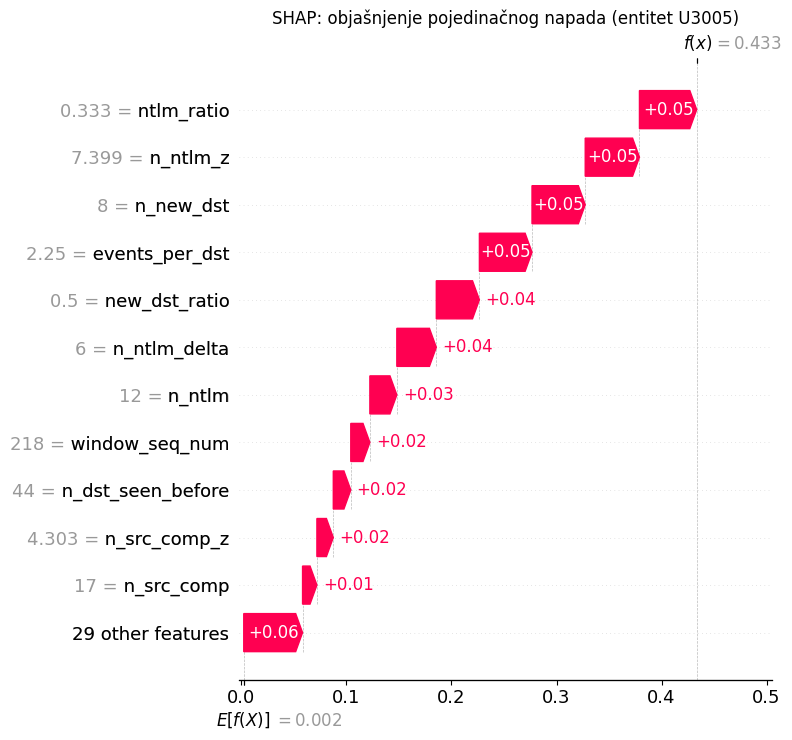

Grafik sačuvan: results/faza8_shap_waterfall.png


In [ ]:
# --- 7. Waterfall grafik za najsigurniji napad ---
# Waterfall prikazuje kako se predikcija gradi korak po korak. Kreće od osnovne
# vrednosti (prosečna predikcija modela na celom skupu) i svaki atribut je
# pomera naviše ili naniže do konačne vrednosti za taj konkretan prozor.
idx_prikaz = int(najsigurniji[0])
osnovna_vrednost = (
    explainer.expected_value[1]
    if isinstance(explainer.expected_value, (list, np.ndarray))
    else explainer.expected_value
)

objasnjenje = shap.Explanation(
    values=shap_napad[idx_prikaz],
    base_values=osnovna_vrednost,
    data=X_val.iloc[idx_prikaz].values,
    feature_names=kolone,
)

plt.figure(figsize=(9, 6))
shap.plots.waterfall(objasnjenje, max_display=12, show=False)
plt.title(
    f"SHAP: objašnjenje pojedinačnog napada (entitet {val.loc[idx_prikaz, 'entity']})"
)
plt.tight_layout()
plt.savefig(RESULTS / "faza8_shap_waterfall.png", dpi=120)
plt.show()
print("Grafik sačuvan: results/faza8_shap_waterfall.png")

# Nijedan pojedinačni atribut ne odlučuje sam. Doprinosi su ravnomerno
# raspoređeni (+0.01 do +0.05), sa NTLM porodicom i atributima novih odredišta
# kao najjačim, u skladu sa globalnim nalazom iz ćelije 5.
# Model gradi predikciju postepeno, sabiranjem umerenih doprinosa mnogo
# atributa a ne oslanjanjem na jedan dominantan signal.
#  Čak i uz sve te doprinose, konačna verovatnoća
# (0.433) ostaje ispod 0.5.

In [ ]:
# --- 8. Poređenje napadačkih i normalnih prozora ---
# Ako se prosečni SHAP doprinosi za dve klase jasno razlikuju, znači da model
# koristi te atribute upravo da razdvoji napade od normalnog ponašanja, a ne
# samo da fino podešava predikciju unutar iste klase.
shap_napadi = shap_napad[y_val == 1].mean(axis=0)
shap_normalni = shap_napad[y_val == 0].mean(axis=0)

poredjenje = pd.DataFrame(
    {
        "Atribut": kolone,
        "SHAP (napadi)": shap_napadi,
        "SHAP (normalni)": shap_normalni,
        "Razlika": shap_napadi - shap_normalni,
    }
).sort_values("Razlika", key=abs, ascending=False)

print("Prosečan SHAP doprinos: napadi naspram normalnih prozora")
print(poredjenje.head(10).to_string(index=False))

poredjenje.to_csv(RESULTS / "faza8_shap_napadi_vs_normalni.csv", index=False)
print("\nSačuvano: results/faza8_shap_napadi_vs_normalni.csv")

# Za svih top 10 atributa prosečan SHAP doprinos napada je pozitivan
# (0.002-0.014), dok je kod normalnih prozora blizu nule. Model
# ove atribute koristi baš da razdvoji napade od normalnog
# ponašanja, a ne da menja predikciju nezavisno od toga da li je
# nešto stvarno napad. Rangiranje se poklapa sa globalnim nalazom
# iz prethodnih ćelija.

Prosečan SHAP doprinos: napadi naspram normalnih prozora
          Atribut  SHAP (napadi)  SHAP (normalni)  Razlika
       ntlm_ratio       0.014314        -0.000143 0.014456
         n_ntlm_z       0.007919        -0.000067 0.007986
     n_ntlm_delta       0.007419        -0.000143 0.007562
           n_ntlm       0.006343        -0.000152 0.006495
    new_dst_ratio       0.005639        -0.000196 0.005835
        n_new_dst       0.005222        -0.000309 0.005532
   window_seq_num       0.004825         0.000961 0.003864
n_dst_seen_before       0.003989         0.000302 0.003687
   events_per_dst       0.003059         0.000221 0.002838
       n_src_comp       0.002249        -0.000153 0.002401

Sačuvano: results/faza8_shap_napadi_vs_normalni.csv


In [ ]:
# --- 9. Poređenje sa MITRE ATT&CK tehnikama ---
# Poslednji korak povezuje empirijski nalaz (koji atributi najviše utiču na
# predikciju i u kom smeru) sa poznatim taktikama i tehnikama lateralnog
# kretanja iz MITRE ATT&CK okvira.
mitre_mapiranje = pd.DataFrame(
    [
        {
            "Atribut": "ntlm_ratio, n_ntlm, n_ntlm_delta, n_ntlm_z, n_ntlm_ma24",
            "Nalaz": "Najuticajniji atributi, dosledno pozitivan SHAP za napade",
            "MITRE taktika/tehnika": "T1550.002 - Use Alternate Authentication Material: Pass the Hash",
            "Obrazloženje": "Visok udeo/broj NTLM autentifikacija je indikator Pass-the-Hash tehnike, gde se ukradeni NTLM heš koristi umesto lozinke",
        },
        {
            "Atribut": "n_new_dst, new_dst_ratio, n_dst_seen_before",
            "Nalaz": "Visoke vrednosti (širenje ka novim računarima) guraju ka napadu",
            "MITRE taktika/tehnika": "TA0008 - Lateral Movement (T1021 - Remote Services)",
            "Obrazloženje": "Pristup računarima kojima entitet ranije nije pristupao odgovara obrascu taktike Lateral Movement. T1021 (Remote Services) je jedna od tehnika koje bi taj obrazac mogle objasniti, iako auth.txt ne beleži konkretan servis/protokol pa se ne može utvrditi da li je baš ta tehnika korišćena",
        },
        {
            "Atribut": "events_per_dst",
            "Nalaz": "Niske vrednosti (razuđena aktivnost na više odredišta) guraju ka napadu",
            "MITRE taktika/tehnika": "Opšti obrazac taktike Lateral Movement (TA0008)",
            "Obrazloženje": "Malo događaja po odredištu na više različitih računara može da predstavlja obrazac širenja kroz mrežu",
        },
    ]
)

print("Poređenje SHAP nalaza sa MITRE ATT&CK tehnikama:")
print(mitre_mapiranje.to_string(index=False))

mitre_mapiranje.to_csv(RESULTS / "faza8_mitre_mapiranje.csv", index=False)
print("\nSačuvano: results/faza8_mitre_mapiranje.csv")

# Napomena: kerberos_ratio (povezan sa Pass-the-Ticket, T1550.003) ima nizak
# SHAP uticaj (van top 10). U ovom skupu podataka redteam napadi
# ostavljaju NTLM trag, ne Kerberos.

Poređenje SHAP nalaza sa MITRE ATT&CK tehnikama:
                                                Atribut                                                                   Nalaz                                            MITRE taktika/tehnika                                                                                                                                                                                                                                                                                   Obrazloženje
ntlm_ratio, n_ntlm, n_ntlm_delta, n_ntlm_z, n_ntlm_ma24               Najuticajniji atributi, dosledno pozitivan SHAP za napade T1550.002 - Use Alternate Authentication Material: Pass the Hash                                                                                                                                                                       Visok udeo/broj NTLM autentifikacija je indikator Pass-the-Hash tehnike, gde se ukradeni NTLM heš koristi umesto